# Potato Blight Classification

**by Group 1**


---

## 1: Business Understanding

### 1.1 Business Context

Potato farming is one of the most economically significant agricultural activities in Sub-Saharan Africa, South Asia, and Latin America, where smallholder farmers depend on potato yields for both subsistence and income. However, potato crops are highly vulnerable to fungal diseases — most notably **Early Blight** (*Alternaria solani*) and **Late Blight** (*Phytophthora infestans*). Left undetected, these diseases can devastate 30–70% of a crop, causing severe food insecurity and financial loss.

Traditional disease identification relies on experts conducting in-person field inspections — a resource that most smallholder farmers cannot access in time. By the point visible symptoms have spread, the window for effective treatment is often already closed.

This project builds an **automated potato blight classification system** using the PlantVillage dataset and a MobileNetV2 deep learning architecture. The model classifies leaf images into three categories — **Early Blight**, **Late Blight**, and **Healthy** — enabling rapid, low-cost diagnosis directly from a smartphone photo.


### 1.2 Stakeholders

| Stakeholder | Interest |
|---|---|
| **Smallholder Farmers** | Early, accurate disease diagnosis to protect yield and income |
| **Agricultural Officers** | A scalable tool to assist field services |
| **NGOs & Food Security Bodies** | Reduction of crop loss in vulnerable communities |
| **Data / ML Teams** | Reproducible, maintainable model pipeline |

### 1.3 Project Plan (CRISP-DM Phases)

```
Phase 1: Business Understanding
Phase 2: Data Understanding
Phase 3: Data Preparation
Phase 4: Modeling
Phase 5: Evaluation
Phase 6: Deployment
```

**Deliverables:**
- Jupyter Notebook 
- GitHub Repository
- Deployment
- Non-Technical Presentation

---

## 2: Data Understanding

### 2.1 Overview — PlantVillage Potato Subset

The dataset is sourced from the **PlantVillage** project, a large-scale open dataset of plant leaf imagery developed at Penn State University. The full PlantVillage dataset covers 38 disease classes across 14 crop species; this project uses the **potato subset only**, consisting of 2,152 images across three classes.

| Class Folder | Disease | Images (approx.) | Share |
|---|---|---|---|
| `Potato___Early_blight` | *Alternaria solani* fungal infection | 1,000 | ~46 % |
| `Potato___Late_blight` | *Phytophthora infestans* water mould | 1,000 | ~46 % |
| `Potato___healthy` | No visible disease | 152 | ~7 % |



### 2.2 Import Libraries

In [12]:
pip install opencv-python

In [13]:
# Import libraries

import os
import cv2
import PIL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import (
    layers, Model, Sequential
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow  : {tf.__version__}')
print(f'GPUs visible: {len(tf.config.list_physical_devices("GPU"))}')

TensorFlow  : 2.3.1
GPUs visible: 0


### 2.3 Configuration

In [14]:
# for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Hyper-parameters 
IMG_SIZE    = 224          # MobileNetV2 expects 224×224
BATCH_SIZE  = 32
EPOCHS_HEAD = 15           # train only the new head
EPOCHS_FINE = 20           # fine-tune top layers of base
LR_HEAD     = 1e-3
LR_FINE     = 5e-5
UNFREEZE_FROM = 130        # unfreeze MobileNetV2 layers from this index onward

CLASS_NAMES = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
LABEL_MAP   = {c: i for i, c in enumerate(CLASS_NAMES)}
DISPLAY_NAMES = ['Early Blight', 'Late Blight', 'Healthy']


DATASET_DIR = 'PlantVillage'  
CHECKPOINT_PATH = 'best_potato_model.h5'

### 2.4 Class Distribution

In [15]:
def count_images(dataset_dir, class_names):
    records = []
    for cls in class_names:
        cls_path = os.path.join(dataset_dir, cls)
        files = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        records.append({
            'class':   cls,
            'display': DISPLAY_NAMES[CLASS_NAMES.index(cls)],
            'count':   len(files)
        })
    return pd.DataFrame(records)

dist_df = count_images(DATASET_DIR, CLASS_NAMES)
dist_df['pct'] = (dist_df['count'] / dist_df['count'].sum() * 100).round(1)
print(dist_df[['display', 'count', 'pct']].to_string(index=False))
print(f"\nTotal images: {dist_df['count'].sum()}")

      display  count   pct
 Early Blight   1000  46.5
  Late Blight   1000  46.5
      Healthy    152   7.1

Total images: 2152


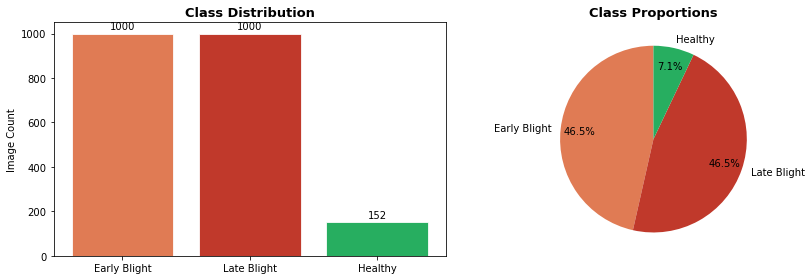

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e07b54', '#c0392b', '#27ae60']

axes[0].bar(dist_df['display'], dist_df['count'], color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Image Count')
for bar, cnt in zip(axes[0].patches, dist_df['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(cnt), ha='center', va='bottom', fontsize=10)

axes[1].pie(dist_df['count'], labels=dist_df['display'], colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.8)
axes[1].set_title('Class Proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights**

`Class Imbalance:` The healthy class accounts for only ~7% of the dataset. Without corrective measures (class weighting), a naive model could achieve ~93% accuracy by simply predicting disease every time — while entirely failing to identify healthy plants. This is why Macro F1 is the primary metric.


### 2.5 Sample Image Grid

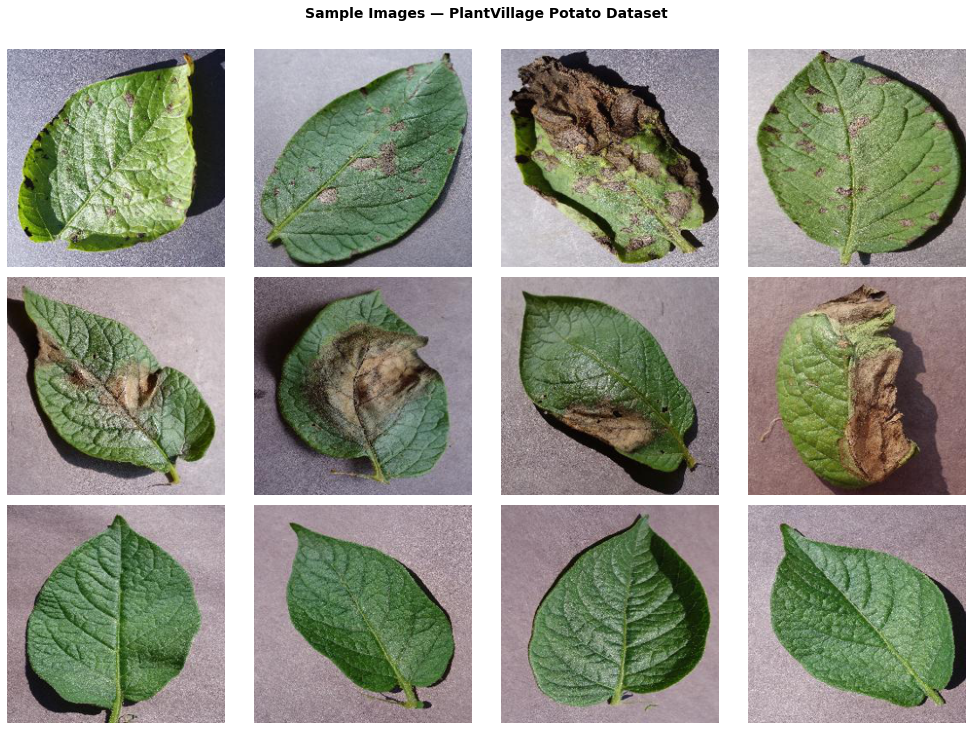

In [17]:
from PIL import Image

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample Images — PlantVillage Potato Dataset', fontsize=14, fontweight='bold', y=1.01)

for row, (cls, dname) in enumerate(zip(CLASS_NAMES, DISPLAY_NAMES)):
    cls_dir = os.path.join(DATASET_DIR, cls)
    samples = np.random.choice(os.listdir(cls_dir), 4, replace=False)
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(cls_dir, fname)).resize((224, 224))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(dname, fontsize=11, fontweight='bold', rotation=0,
                                      labelpad=80, va='center')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 3: Data Preparation

### 3.1 Build File List & Stratified Split

In [18]:
def build_file_list(dataset_dir, class_names):
    """Return (paths, labels) arrays with integer label encoding."""
    paths, labels = [], []
    for cls in class_names:
        cls_dir = os.path.join(dataset_dir, cls)
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(LABEL_MAP[cls])
    return np.array(paths), np.array(labels)
all_paths, all_labels = build_file_list(DATASET_DIR, CLASS_NAMES)
print(f'Total files loaded: {len(all_paths)}')
# Stratified split: 70 % train / 15 % val / 15 % test
X_train, X_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, 
random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
print(f'Train : {len(X_train)} images')
print(f'Val   : {len(X_val)}  images')
print(f'Test  : {len(X_test)}  images')

Total files loaded: 2152
Train : 1506 images
Val   : 323  images
Test  : 323  images


**Insights**

`Why stratified splits?` Stratification ensures each split preserves the original class
proportions. 

Without it, the rare healthy class (only ~152 images) could be randomly
absent or over-concentrated in one split, making validation metrics unreliable.

### 3.2. Class Weights

In [19]:
class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights_arr))

Interpretation: compute_class_weight('balanced', ...) assigns each class a weightinversely proportional to its frequency. The healthy class will receive a much higherweight (~6–7×) than the disease classes, penalising the model more heavily formisclassifying the rare class during training.


### 3.3. tf.data Pipeline

In [34]:

AUTOTUNE = tf.data.experimental.AUTOTUNE
def load_and_preprocess_image(path, label):
    """Read image, resize, scale to [-1, 1] (MobileNetV2 convention)."""
    raw   = tf.io.read_file(path)
    image = tf.image.decode_image(raw, channels=3)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label
    
def augment(image, label):
    """Augmentation applied only during training."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    image = tf.image.random_hue(image, 0.05)
    frac     = tf.random.uniform([], 0.85, 1.0)
    crop_sz  = tf.cast(tf.cast(IMG_SIZE, tf.float32) * frac, tf.int32)
    image    = tf.image.random_crop(image, [crop_sz, crop_sz, 3])
    image    = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image    = tf.clip_by_value(image, -1.0, 1.0)
    return image, label

def make_dataset(paths, labels, augment_flag=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if augment_flag:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds
# ds.shuffle shuffles the order of images (training only)
# ds.map reads each image file, resizes to 224x224, scales pixel values to 
[-1, 1]
# augment applies random flips, brightness, crop etc. (training only)
# ds.batch roups images into batches of 32
# prefetch loads the next batch in the background while the model trains on the current one

train_ds = make_dataset(X_train, y_train, augment_flag=True,  shuffle=True)
val_ds   = make_dataset(X_val,   y_val,   augment_flag=False, shuffle=False)
test_ds  = make_dataset(X_test,  y_test,  augment_flag=False, shuffle=False)
print('Datasets ready.')
for images, labels in train_ds.take(1):
    print(f'  Batch shape: {images.shape}, label dtype: {labels.dtype}')



Datasets ready.
  Batch shape: (32, 224, 224, 3), label dtype: <dtype: 'int32'>


**Augmentation rationale**: With only 2,152 images, the training set is small enough that
overfitting is a real risk. The augmentation pipeline applies a range of realistic
photometric and geometric transforms (flips, brightness shifts, saturation changes,
random crop) to synthetically expand training diversity. Augmentation is applied only to
the training set — validation and test sets always use the clean, unmodified images to
ensure the evaluation reflects real-world deployment conditions.